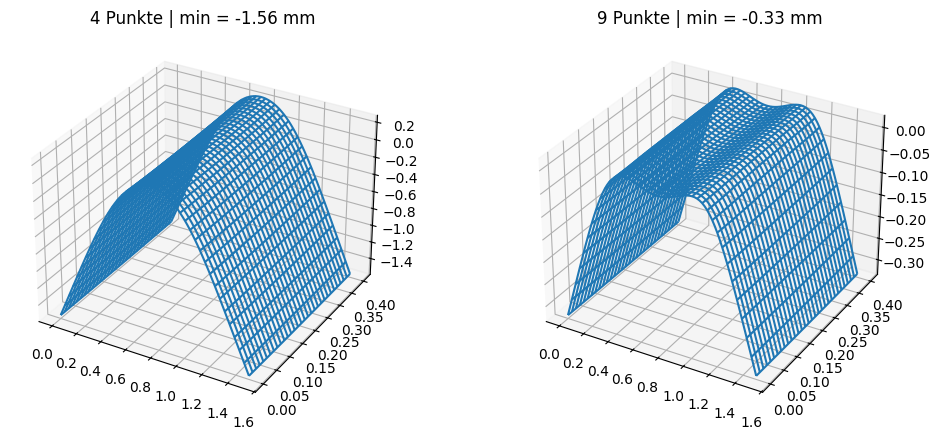

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# -----------------------------
# Geometrie + Material
# -----------------------------
Lx = 1.5
Ly = 0.4
h = 0.008
E = 70e9
nu = 0.23
rho = 2500.0
g = 9.81

q = rho * h * g
D = E * h**3 / (12 * (1 - nu**2))

# -----------------------------
# Gitter
# -----------------------------
Nx = 81
Ny = 31

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

n = Nx * Ny

def idx(i, j):
    return j * Nx + i

# -----------------------------
# Ableitungen
# -----------------------------
rows_xx, rows_yy, rows_xy = [], [], []
row = 0

for j in range(1, Ny-1):
    for i in range(1, Nx-1):
        # w_xx
        rows_xx += [
            (row, idx(i-1,j),  1/dx**2),
            (row, idx(i,j),   -2/dx**2),
            (row, idx(i+1,j),  1/dx**2),
        ]
        # w_yy
        rows_yy += [
            (row, idx(i,j-1),  1/dy**2),
            (row, idx(i,j),   -2/dy**2),
            (row, idx(i,j+1),  1/dy**2),
        ]
        # w_xy
        rows_xy += [
            (row, idx(i+1,j+1),  1/(4*dx*dy)),
            (row, idx(i-1,j-1),  1/(4*dx*dy)),
            (row, idx(i+1,j-1), -1/(4*dx*dy)),
            (row, idx(i-1,j+1), -1/(4*dx*dy)),
        ]
        row += 1

m = (Nx-2)*(Ny-2)

def build(rows):
    A = lil_matrix((m, n))
    for r,c,v in rows:
        A[r,c] += v
    return A.tocsr()

Lxx = build(rows_xx)
Lyy = build(rows_yy)
Lxy = build(rows_xy)

area = dx * dy

# -----------------------------
# System
# -----------------------------
A = D * area * (
    Lxx.T @ Lxx +
    Lyy.T @ Lyy +
    nu * (Lxx.T @ Lyy + Lyy.T @ Lxx) +
    2 * (1 - nu) * (Lxy.T @ Lxy)
)

A = A.tolil()
b = np.ones(n) * (-q * area)

# Stabilisierung
for i in range(n):
    A[i,i] += 1e-6

# -----------------------------
# Auflager
# -----------------------------
k_support = 1e12

def solve(supports):
    A2 = A.copy().tolil()
    b2 = b.copy()

    for x,y in supports:
        i = int(round(x/dx))
        j = int(round(y/dy))
        A2[idx(i,j), idx(i,j)] += k_support

    w = spsolve(A2.tocsr(), b2)
    return w.reshape((Ny, Nx))

# 4-Punkt
supports_4 = [
    (0.5, 0.133), (1.0, 0.133),
    (0.5, 0.267), (1.0, 0.267)
]

# 9-Punkt
supports_9 = [
    (0.375,0.1),(0.75,0.1),(1.125,0.1),
    (0.375,0.2),(0.75,0.2),(1.125,0.2),
    (0.375,0.3),(0.75,0.3),(1.125,0.3)
]

W1 = solve(supports_4)
W2 = solve(supports_9)

# -----------------------------
# Plot
# -----------------------------
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(1,2,1, projection='3d')
ax.plot_wireframe(X, Y, W1*1000)
ax.set_title(f"4 Punkte | min = {np.min(W1)*1000:.2f} mm")

ax = fig.add_subplot(1,2,2, projection='3d')
ax.plot_wireframe(X, Y, W2*1000)
ax.set_title(f"9 Punkte | min = {np.min(W2)*1000:.2f} mm")

plt.show()